# Лабораторная работа 2. Спайковые нейронные сети

## Цель работы
Практически освоить принципы нейроморфных вычислений через моделирование и анализ простой спайковой нейронной сети (SNN).



## 1. Теоретическая часть

### 1.1. Нейроморфные вычисления и SNN
Спайковые нейронные сети отличаются от обычных ИНС тем, что работают не с непрерывными активациями, а с **событиями во времени** — спайками.  
Это делает их естественным выбором для обработки временных сигналов и событийных потоков.

Преимущества SNN:
- естественная работа со временем;
- разреженная активация;
- потенциально высокая энергоэффективность;
- близость к биологическим механизмам обучения.

### 1.2. Модель LIF
Модель **Leaky Integrate-and-Fire** описывается уравнением:

$$
\tau_m \frac{dV(t)}{dt} = -(V(t)-V_{rest}) + R_m I(t)
$$

где:
- $V(t)$ — мембранный потенциал;
- $V_{rest}$ — потенциал покоя;
- $R_m I(t)$ — вклад входного тока;
- $\tau_m$ — постоянная времени мембраны.

Если $V(t) \ge V_{th}$, нейрон генерирует спайк, затем потенциал сбрасывается к $V_{reset}$.

### 1.3. STDP
Правило **Spike-Timing Dependent Plasticity** изменяет вес в зависимости от разности времен между пре- и постсинаптическим спайками:

$$
\Delta w =
\begin{cases}
A_+ \exp(-\Delta t/\tau_+), & \Delta t > 0 \\
-A_- \exp(\Delta t/\tau_-), & \Delta t < 0
\end{cases}
$$

где $\Delta t = t_{post} - t_{pre}$.

Интерпретация:
- если пресинаптический нейрон активируется **чуть раньше** постсинаптического, связь усиливается;
- если **позже**, связь ослабляется.

### 1.4. Обучение с учителем через surrogate gradient
Классическая проблема SNN: спайк-функция недифференцируема.  
Поэтому при обратном распространении ошибки вместо точной производной пороговой функции используют **суррогатную производную**.

Идея:
- в прямом проходе использовать обычный бинарный спайк;
- в обратном проходе заменить нулевую производную на гладкую аппроксимацию около порога.

Это позволяет обучать SNN почти так же, как обычные нейросети, но при этом сохранять спайковую динамику.


In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import List, Tuple

import torch
import torch.nn as nn
import torch.optim as optim

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print('Torch version:', torch.__version__)
print('Используем device:', 'cuda' if torch.cuda.is_available() else 'cpu')


Torch version: 2.10.0+cpu
Используем device: cpu


## 2. Моделирование LIF-нейрона

In [2]:
@dataclass
class LIFNeuron:
    tau_m: float = 20.0
    v_rest: float = -70.0
    v_thresh: float = -55.0
    v_reset: float = -75.0
    r_m: float = 10.0
    tau_ref: float = 4.0

    def __post_init__(self):
        self.reset_state()

    def reset_state(self):
        self.v = self.v_rest
        self.refractory_until = -np.inf
        self.spike_times = []

    def step(self, I_inj: float, dt: float, t: float) -> bool:
        if t < self.refractory_until:
            self.v = self.v_reset
            return False

        dv = (-(self.v - self.v_rest) + self.r_m * I_inj) / self.tau_m
        self.v += dv * dt

        if self.v >= self.v_thresh:
            self.v = self.v_reset
            self.refractory_until = t + self.tau_ref
            self.spike_times.append(t)
            return True
        return False


def simulate_lif(neuron: LIFNeuron, I_inj: np.ndarray, dt: float, T: float):
    neuron.reset_state()
    t_range = np.arange(0, T, dt)
    v_trace = []
    spikes = []

    for i, t in enumerate(t_range):
        spk = neuron.step(float(I_inj[i]), dt, float(t))
        v_trace.append(neuron.v)
        spikes.append(int(spk))

    return t_range, np.array(v_trace), np.array(spikes), neuron.spike_times


def plot_neuron_activity(t_range, v_trace, spike_times, neuron, title='Активность LIF-нейрона'):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

    ax1.plot(t_range, v_trace)
    ax1.axhline(neuron.v_thresh, linestyle='--', label='Порог')
    ax1.axhline(neuron.v_rest, linestyle='--', label='Покой')
    ax1.set_ylabel('Потенциал, мВ')
    ax1.set_title(title)
    ax1.grid(True)
    ax1.legend()

    ax2.eventplot(spike_times, linewidths=2)
    ax2.set_xlabel('Время, мс')
    ax2.set_ylabel('Спайки')
    ax2.set_yticks([])
    ax2.grid(True)

    plt.tight_layout()
    plt.show()


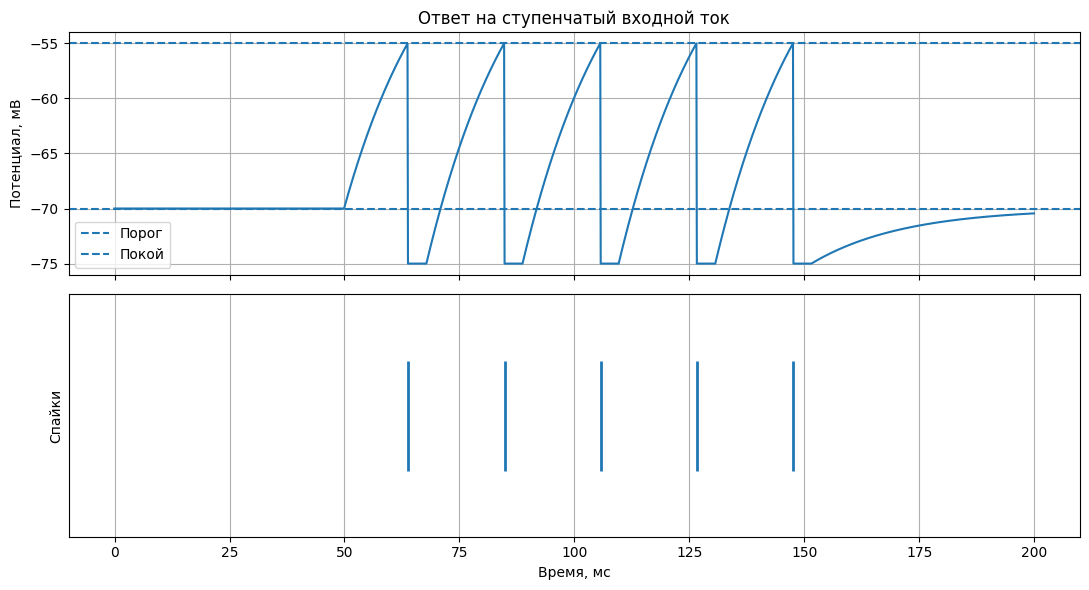

Количество спайков: 5
Частота на активном интервале ~ 50.0 спайк/с (приближенно)


In [3]:
# Ответ LIF-нейрона на ступенчатый ток
dt = 0.1
T = 200.0
t_range = np.arange(0, T, dt)

neuron = LIFNeuron()
I_step = np.zeros_like(t_range)
I_step[(t_range >= 50) & (t_range <= 150)] = 3.0

t_range, v_trace, spikes, spike_times = simulate_lif(neuron, I_step, dt, T)
plot_neuron_activity(t_range, v_trace, spike_times, neuron, title='Ответ на ступенчатый входной ток')

print('Количество спайков:', int(spikes.sum()))
print('Частота на активном интервале ~', round(spikes.sum() / 0.1, 2), 'спайк/с (приближенно)')


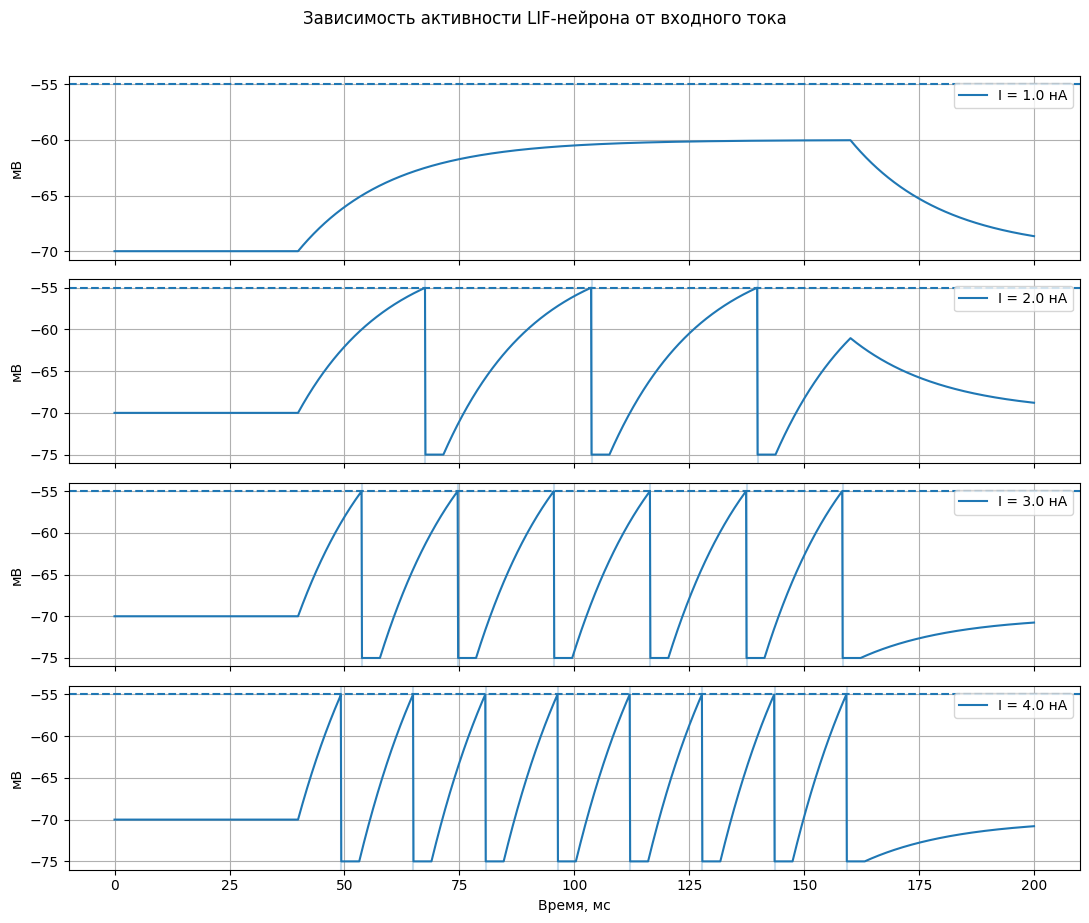

In [4]:
# Исследование реакции на разные уровни тока
currents = [1.0, 2.0, 3.0, 4.0]
fig, axes = plt.subplots(len(currents), 1, figsize=(11, 9), sharex=True)

for ax, current in zip(axes, currents):
    neuron = LIFNeuron()
    I = np.zeros_like(t_range)
    I[(t_range >= 40) & (t_range <= 160)] = current
    _, v, s, spk_times = simulate_lif(neuron, I, dt, T)

    ax.plot(t_range, v, label=f'I = {current} нА')
    ax.axhline(neuron.v_thresh, linestyle='--')
    for st in spk_times:
        ax.axvline(st, alpha=0.25)
    ax.set_ylabel('мВ')
    ax.grid(True)
    ax.legend(loc='upper right')

axes[-1].set_xlabel('Время, мс')
fig.suptitle('Зависимость активности LIF-нейрона от входного тока', y=1.02)
plt.tight_layout()
plt.show()



При увеличении входного тока мембранный потенциал быстрее достигает порога, и частота спайков возрастает.  
Это подтверждает ожидаемую динамику модели LIF: нейрон интегрирует вход, а утечка препятствует бесконечному росту потенциала.


## 3. Простая сеть из LIF-нейронов и распространение спайков

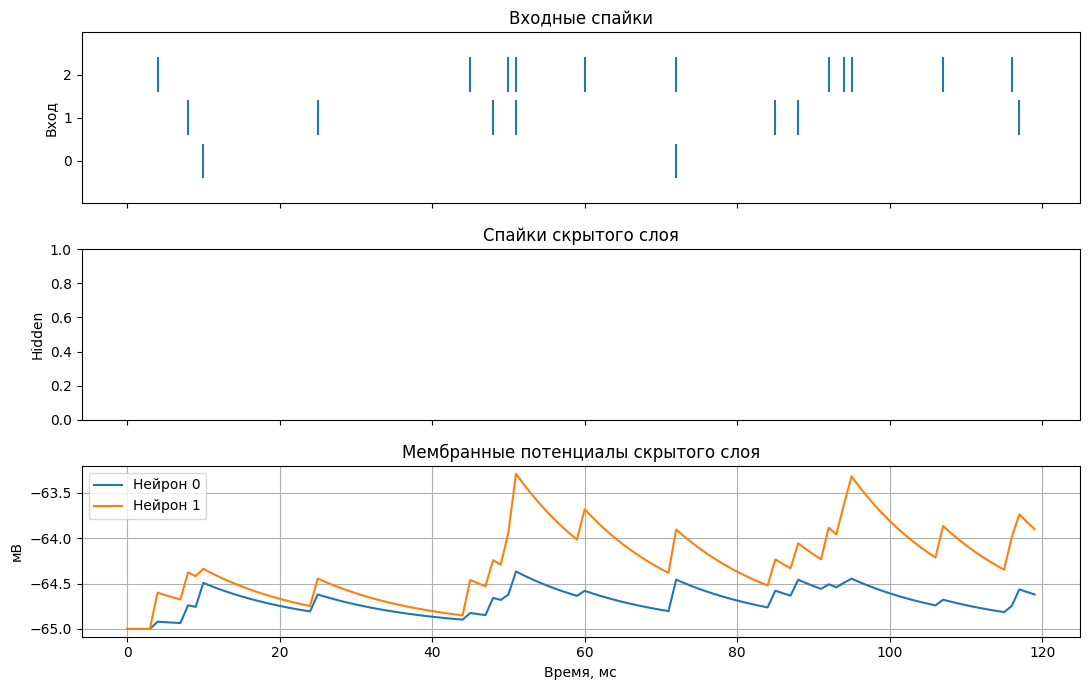

Матрица весов вход -> скрытый слой:
[[4.2       1.8000001]
 [3.        4.8      ]
 [1.2       6.       ]]
Число спайков во входном слое: 20
Число спайков в скрытом слое: 0


In [5]:
def poisson_spike_train(rate_hz: float, T: float, dt: float):
    steps = int(T / dt)
    p = rate_hz * dt / 1000.0
    return (np.random.rand(steps) < p).astype(np.float32)


def simulate_feedforward_snn(T=120.0, dt=1.0, w_scale=6.0):
    steps = int(T / dt)
    n_in, n_hidden = 3, 2

    input_spikes = np.zeros((steps, n_in), dtype=np.float32)
    input_spikes[:, 0] = poisson_spike_train(25, T, dt)
    input_spikes[:, 1] = poisson_spike_train(45, T, dt)
    input_spikes[:, 2] = poisson_spike_train(65, T, dt)

    W = np.array([[0.7, 0.3],
                  [0.5, 0.8],
                  [0.2, 1.0]], dtype=np.float32) * w_scale

    neurons = [LIFNeuron(tau_m=15.0, r_m=1.0, v_thresh=-58.0, v_rest=-65.0, v_reset=-68.0, tau_ref=3.0)
               for _ in range(n_hidden)]

    hidden_spikes = np.zeros((steps, n_hidden), dtype=np.float32)
    hidden_v = np.zeros((steps, n_hidden), dtype=np.float32)

    time_points = np.arange(0, T, dt)
    for t_idx, t in enumerate(time_points):
        syn_current = input_spikes[t_idx] @ W
        for j in range(n_hidden):
            spk = neurons[j].step(float(syn_current[j]), dt, float(t))
            hidden_spikes[t_idx, j] = float(spk)
            hidden_v[t_idx, j] = neurons[j].v

    return time_points, input_spikes, hidden_spikes, hidden_v, W


time_points, input_spikes, hidden_spikes, hidden_v, W = simulate_feedforward_snn()

fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)

for i in range(input_spikes.shape[1]):
    spike_times = time_points[input_spikes[:, i] > 0]
    axes[0].eventplot(spike_times, lineoffsets=i, linelengths=0.8)
axes[0].set_title('Входные спайки')
axes[0].set_ylabel('Вход')

for j in range(hidden_spikes.shape[1]):
    spike_times = time_points[hidden_spikes[:, j] > 0]
    axes[1].eventplot(spike_times, lineoffsets=j, linelengths=0.8)
axes[1].set_title('Спайки скрытого слоя')
axes[1].set_ylabel('Hidden')

for j in range(hidden_v.shape[1]):
    axes[2].plot(time_points, hidden_v[:, j], label=f'Нейрон {j}')
axes[2].set_title('Мембранные потенциалы скрытого слоя')
axes[2].set_xlabel('Время, мс')
axes[2].set_ylabel('мВ')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

print('Матрица весов вход -> скрытый слой:')
print(W)
print('Число спайков во входном слое:', int(input_spikes.sum()))
print('Число спайков в скрытом слое:', int(hidden_spikes.sum()))


**Наблюдение.**  
Спайковая активность скрытого слоя зависит не только от количества входных спайков, но и от их распределения по времени и весам синапсов.  
Это показывает, что даже простая SNN чувствительна к временному коду.


## 4. Реализация STDP и анализ изменения весов

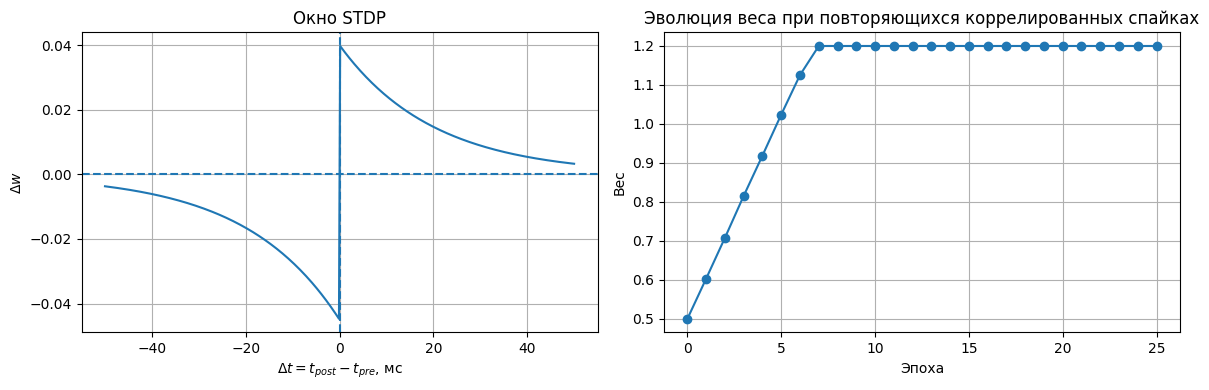

Начальный вес: 0.5
Финальный вес: 1.2


In [6]:
def stdp_update(delta_t, A_plus=0.04, A_minus=0.045, tau_plus=20.0, tau_minus=20.0):
    if delta_t > 0:
        return A_plus * np.exp(-delta_t / tau_plus)
    elif delta_t < 0:
        return -A_minus * np.exp(delta_t / tau_minus)
    return 0.0


def run_stdp_demo(num_epochs=25, w_init=0.5, w_min=0.0, w_max=1.2):
    pre_spikes = np.array([20, 45, 70, 95], dtype=float)
    # постсинаптические спайки слегка позже пресинаптических -> ожидаем усиление
    post_spikes_template = np.array([24, 49, 74, 100], dtype=float)

    w = w_init
    history = [w]

    for epoch in range(num_epochs):
        post_spikes = post_spikes_template + np.random.normal(0, 1.0, size=len(post_spikes_template))
        for t_pre in pre_spikes:
            for t_post in post_spikes:
                dw = stdp_update(t_post - t_pre)
                w = np.clip(w + dw, w_min, w_max)
        history.append(w)

    return pre_spikes, post_spikes_template, np.array(history)


pre_spikes, post_spikes_template, w_hist = run_stdp_demo()

delta_t = np.linspace(-50, 50, 400)
dw_curve = np.array([stdp_update(x) for x in delta_t])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(delta_t, dw_curve)
axes[0].axhline(0, linestyle='--')
axes[0].axvline(0, linestyle='--')
axes[0].set_title('Окно STDP')
axes[0].set_xlabel(r'$\Delta t = t_{post} - t_{pre}$, мс')
axes[0].set_ylabel(r'$\Delta w$')
axes[0].grid(True)

axes[1].plot(w_hist, marker='o')
axes[1].set_title('Эволюция веса при повторяющихся коррелированных спайках')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Вес')
axes[1].grid(True)

plt.tight_layout()
plt.show()

print('Начальный вес:', round(float(w_hist[0]), 4))
print('Финальный вес:', round(float(w_hist[-1]), 4))


По графикам видно, что правило STDP работает корректно: при положительном временном сдвиге между пресинаптическим и постсинаптическим спайками вес увеличивается, а при отрицательном — уменьшается. Также видно, что при повторяющихся коррелированных спайках синаптический вес сначала растёт, а затем стабилизируется на верхнем уровне.


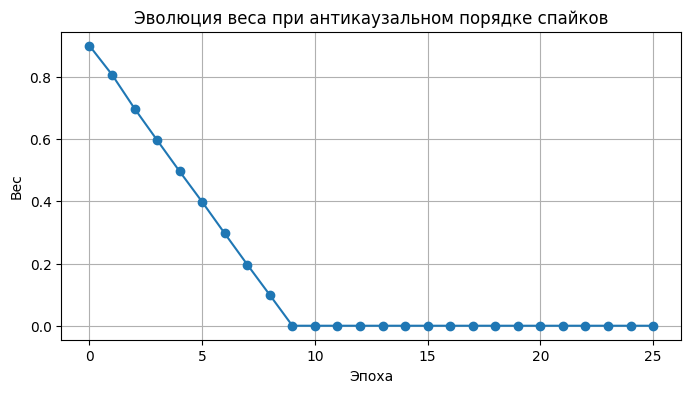

Начальный вес: 0.9
Финальный вес: 0.0


In [7]:
# Демонстрация случая, когда пост-спайк приходит раньше пре-спайка -> ожидаем депрессию
def run_stdp_depression_demo(num_epochs=25, w_init=0.9, w_min=0.0, w_max=1.2):
    pre_spikes = np.array([25, 50, 75, 100], dtype=float)
    post_spikes_template = np.array([18, 44, 68, 92], dtype=float)

    w = w_init
    history = [w]

    for epoch in range(num_epochs):
        post_spikes = post_spikes_template + np.random.normal(0, 1.0, size=len(post_spikes_template))
        for t_pre in pre_spikes:
            for t_post in post_spikes:
                dw = stdp_update(t_post - t_pre)
                w = np.clip(w + dw, w_min, w_max)
        history.append(w)

    return np.array(history)

w_hist_dep = run_stdp_depression_demo()

plt.figure(figsize=(8, 4))
plt.plot(w_hist_dep, marker='o')
plt.title('Эволюция веса при антикаузальном порядке спайков')
plt.xlabel('Эпоха')
plt.ylabel('Вес')
plt.grid(True)
plt.show()

print('Начальный вес:', round(float(w_hist_dep[0]), 4))
print('Финальный вес:', round(float(w_hist_dep[-1]), 4))


По графику видно, что при антикаузальном порядке спайков синаптический вес постепенно уменьшается от 0.9 до 0.0. Это показывает, что STDP ослабляет связь, если постсинаптический нейрон активируется раньше пресинаптического.

## 5. Классификация простых паттернов с помощью SNN

Чтобы лабораторная работа выполнялась быстро и воспроизводимо, ниже используется **синтетический набор временных паттернов**.  
Каждый образец содержит 6 входных каналов и 20 временных шагов.

Классы:
- **класс 0**: ранние спайки в первых трёх каналах;
- **класс 1**: поздние спайки в последних трёх каналах.

Такой датасет хорошо показывает, что SNN умеет различать паттерны не только по числу спайков, но и по **времени их возникновения**.


Train: (480, 20, 6) (480,)
Test : (120, 20, 6) (120,)


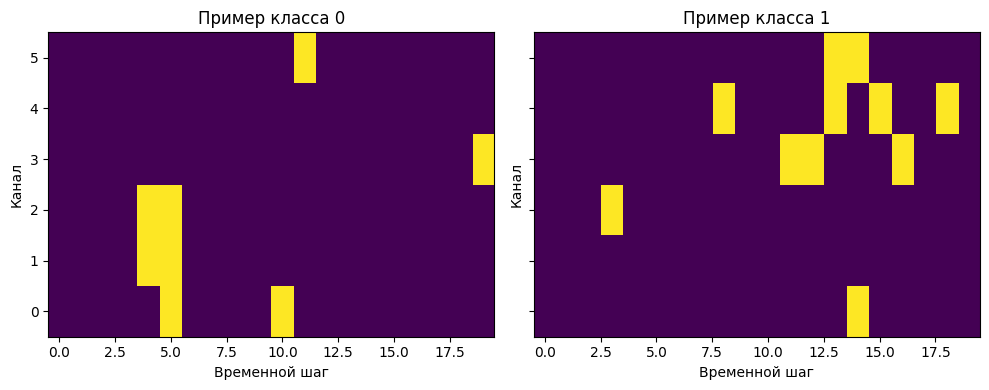

In [8]:
def generate_temporal_dataset(n_samples=1200, time_steps=20, n_inputs=6, noise_prob=0.02):
    X = np.zeros((n_samples, time_steps, n_inputs), dtype=np.float32)
    y = np.zeros(n_samples, dtype=np.int64)

    for i in range(n_samples):
        cls = i % 2
        y[i] = cls

        if cls == 0:
            active_channels = [0, 1, 2]
            center = 5
        else:
            active_channels = [3, 4, 5]
            center = 14

        for ch in active_channels:
            t = int(np.clip(np.random.normal(center, 1.5), 0, time_steps - 1))
            X[i, t, ch] = 1.0
            if np.random.rand() < 0.5 and t + 1 < time_steps:
                X[i, t + 1, ch] = 1.0

        noise = (np.random.rand(time_steps, n_inputs) < noise_prob).astype(np.float32)
        X[i] = np.clip(X[i] + noise, 0, 1)

    idx = np.random.permutation(n_samples)
    return X[idx], y[idx]


X, y = generate_temporal_dataset(n_samples=600)
train_size = int(0.8 * len(X))
X_train, y_train = X[:train_size], y[:train_size]
X_test, y_test = X[train_size:], y[train_size:]

print('Train:', X_train.shape, y_train.shape)
print('Test :', X_test.shape, y_test.shape)

# Визуализация одного примера каждого класса
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for cls in [0, 1]:
    idx = np.where(y_train == cls)[0][0]
    axes[cls].imshow(X_train[idx].T, aspect='auto', origin='lower')
    axes[cls].set_title(f'Пример класса {cls}')
    axes[cls].set_xlabel('Временной шаг')
    axes[cls].set_ylabel('Канал')
plt.tight_layout()
plt.show()


для разных классов формируются разные временные спайковые паттерны: у класса 0 спайки сосредоточены в одних каналах и моментах времени, а у класса 1 — распределены иначе. Это подтверждает, что входные данные закодированы в виде различимых спайковых последовательностей, которые SNN может использовать для классификации.


## 5.1. Обучение с учителем на основе STDP и учительного сигнала (Surrogate Gradient)



In [9]:
class SurrogateSpike(torch.autograd.Function):
    @staticmethod
    def forward(ctx, membrane_minus_threshold):
        ctx.save_for_backward(membrane_minus_threshold)
        return (membrane_minus_threshold > 0).float()

    @staticmethod
    def backward(ctx, grad_output):
        (x,) = ctx.saved_tensors
        beta = 5.0
        grad = beta * torch.exp(-beta * torch.abs(x))
        return grad_output * grad


spike_fn = SurrogateSpike.apply


class SimpleSNN(nn.Module):
    def __init__(self, n_inputs=6, n_hidden=24, n_outputs=2, beta=0.9, threshold=1.0):
        super().__init__()
        self.fc1 = nn.Linear(n_inputs, n_hidden, bias=False)
        self.fc2 = nn.Linear(n_hidden, n_outputs, bias=False)
        self.beta = beta
        self.threshold = threshold

    def forward(self, x):
        # x: [batch, time, input]
        batch_size, time_steps, _ = x.shape
        mem1 = torch.zeros(batch_size, self.fc1.out_features, device=x.device)
        mem2 = torch.zeros(batch_size, self.fc2.out_features, device=x.device)

        spk1_rec = []
        mem2_rec = []

        for t in range(time_steps):
            cur1 = self.fc1(x[:, t, :])
            mem1 = self.beta * mem1 + cur1
            spk1 = spike_fn(mem1 - self.threshold)
            mem1 = mem1 * (1.0 - spk1)  # soft reset

            cur2 = self.fc2(spk1)
            mem2 = self.beta * mem2 + cur2

            spk1_rec.append(spk1)
            mem2_rec.append(mem2)

        spk1_rec = torch.stack(spk1_rec, dim=1)   # [B, T, H]
        mem2_rec = torch.stack(mem2_rec, dim=1)   # [B, T, O]
        logits = mem2_rec.max(dim=1).values       # temporal max pooling
        return logits, spk1_rec, mem2_rec


In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

X_train_t = torch.tensor(X_train, dtype=torch.float32, device=device)
y_train_t = torch.tensor(y_train, dtype=torch.long, device=device)
X_test_t = torch.tensor(X_test, dtype=torch.float32, device=device)
y_test_t = torch.tensor(y_test, dtype=torch.long, device=device)

model = SimpleSNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-2)
criterion = nn.CrossEntropyLoss()

def accuracy_from_logits(logits, target):
    preds = logits.argmax(dim=1)
    return (preds == target).float().mean().item()

history = {'train_loss': [], 'train_acc': [], 'test_acc': [], 'avg_hidden_spikes': []}

batch_size = 64
epochs = 8

for epoch in range(epochs):
    model.train()
    perm = torch.randperm(X_train_t.size(0), device=device)

    epoch_loss = 0.0
    epoch_acc = 0.0
    epoch_spikes = 0.0
    batches = 0

    for i in range(0, X_train_t.size(0), batch_size):
        idx = perm[i:i+batch_size]
        xb = X_train_t[idx]
        yb = y_train_t[idx]

        optimizer.zero_grad()
        logits, spk1_rec, _ = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        epoch_acc += accuracy_from_logits(logits, yb)
        epoch_spikes += spk1_rec.sum(dim=(1, 2)).float().mean().item()
        batches += 1

    model.eval()
    with torch.no_grad():
        test_logits, test_spk1, _ = model(X_test_t)
        test_acc = accuracy_from_logits(test_logits, y_test_t)

    history['train_loss'].append(epoch_loss / batches)
    history['train_acc'].append(epoch_acc / batches)
    history['test_acc'].append(test_acc)
    history['avg_hidden_spikes'].append(epoch_spikes / batches)

    print(f'Эпоха {epoch+1:02d}/{epochs} | loss={history["train_loss"][-1]:.4f} | '
          f'train_acc={history["train_acc"][-1]:.4f} | test_acc={test_acc:.4f} | '
          f'avg_hidden_spikes={history["avg_hidden_spikes"][-1]:.2f}')


Эпоха 01/8 | loss=0.6844 | train_acc=0.6172 | test_acc=0.7750 | avg_hidden_spikes=1.10
Эпоха 02/8 | loss=0.5955 | train_acc=0.8750 | test_acc=0.9417 | avg_hidden_spikes=2.14
Эпоха 03/8 | loss=0.4390 | train_acc=0.9590 | test_acc=0.9833 | avg_hidden_spikes=4.25
Эпоха 04/8 | loss=0.2704 | train_acc=0.9785 | test_acc=0.9917 | avg_hidden_spikes=7.44
Эпоха 05/8 | loss=0.1380 | train_acc=0.9922 | test_acc=0.9917 | avg_hidden_spikes=11.22
Эпоха 06/8 | loss=0.0651 | train_acc=0.9922 | test_acc=0.9833 | avg_hidden_spikes=14.46
Эпоха 07/8 | loss=0.0394 | train_acc=0.9922 | test_acc=0.9833 | avg_hidden_spikes=16.89
Эпоха 08/8 | loss=0.0278 | train_acc=0.9941 | test_acc=0.9833 | avg_hidden_spikes=18.41


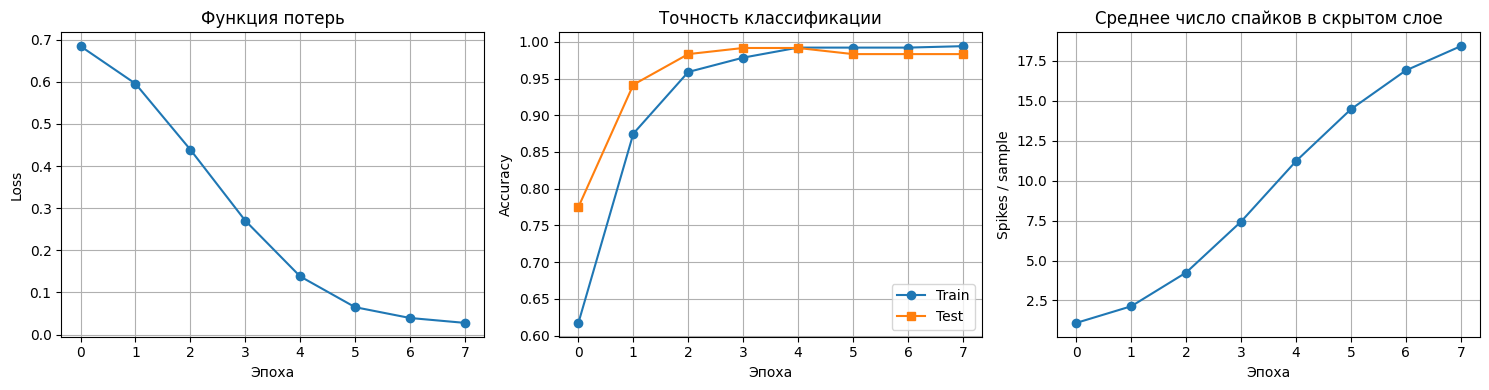

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['train_loss'], marker='o')
axes[0].set_title('Функция потерь')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Loss')
axes[0].grid(True)

axes[1].plot(history['train_acc'], marker='o', label='Train')
axes[1].plot(history['test_acc'], marker='s', label='Test')
axes[1].set_title('Точность классификации')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(history['avg_hidden_spikes'], marker='o')
axes[2].set_title('Среднее число спайков в скрытом слое')
axes[2].set_xlabel('Эпоха')
axes[2].set_ylabel('Spikes / sample')
axes[2].grid(True)

plt.tight_layout()
plt.show()


По графикам видно, что в процессе обучения SNN функция потерь устойчиво уменьшается, а точность классификации на обучающей и тестовой выборках быстро возрастает почти до 1.0. Также видно, что среднее число спайков в скрытом слое увеличивается, то есть сеть активнее использует спайковую динамику для распознавания паттернов.

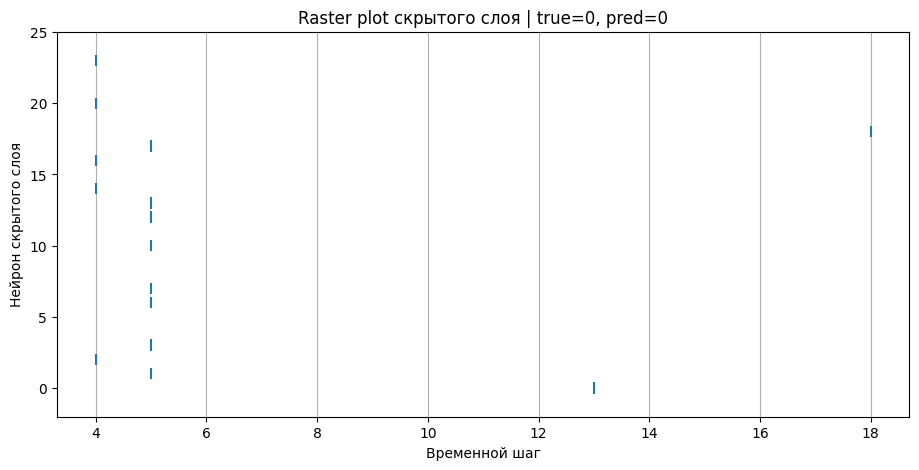

In [12]:
# Raster plot активности скрытого слоя для одного тестового примера
model.eval()
with torch.no_grad():
    sample_idx = 0
    sample_x = X_test_t[sample_idx:sample_idx+1]
    sample_y = y_test_t[sample_idx].item()
    logits, spk1_rec, mem2_rec = model(sample_x)
    pred = logits.argmax(dim=1).item()

spike_mat = spk1_rec[0].detach().cpu().numpy().T  # [H, T]

plt.figure(figsize=(11, 5))
for neuron_idx in range(spike_mat.shape[0]):
    times = np.where(spike_mat[neuron_idx] > 0)[0]
    plt.eventplot(times, lineoffsets=neuron_idx, linelengths=0.8)
plt.title(f'Raster plot скрытого слоя | true={sample_y}, pred={pred}')
plt.xlabel('Временной шаг')
plt.ylabel('Нейрон скрытого слоя')
plt.grid(True, axis='x')
plt.show()


скрытый слой формирует разреженную спайковую активность: спайки возникают только у части нейронов и в отдельных временных шагах. При этом для данного примера сеть правильно классифицировала образец (true=0, pred=0), значит сформированный временной паттерн активности оказался достаточным для распознавания класса.

## 6. Устойчивость к шуму и приближенная оценка энергозатрат

В SNN энергопотребление часто связывают с количеством событий:  
чем меньше спайков, тем меньше вычислительных и аппаратных затрат.

Ниже:
- проверяется точность на зашумленных данных;
- число спайков используется как **приближенная метрика энергозатрат**.


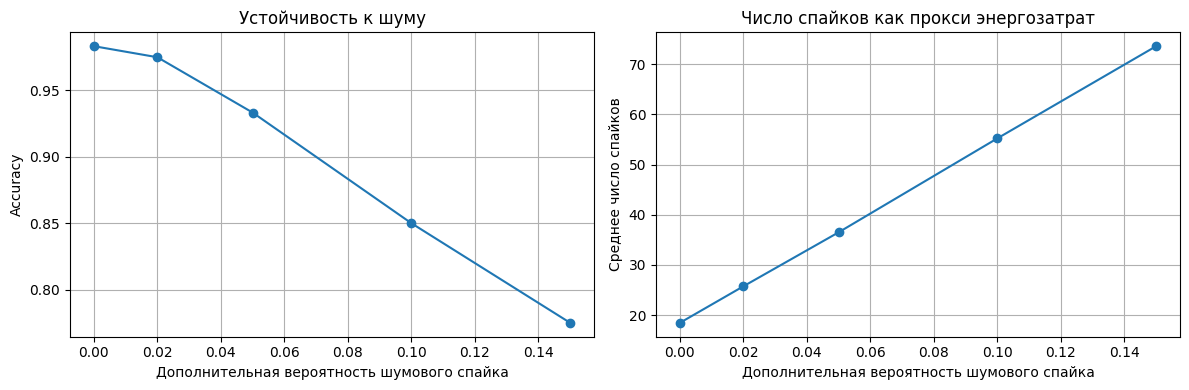

noise=0.00 | acc=0.9833 | avg_hidden_spikes=18.46
noise=0.02 | acc=0.9750 | avg_hidden_spikes=25.74
noise=0.05 | acc=0.9333 | avg_hidden_spikes=36.51
noise=0.10 | acc=0.8500 | avg_hidden_spikes=55.24
noise=0.15 | acc=0.7750 | avg_hidden_spikes=73.62


In [13]:
def add_noise_to_dataset(X, extra_noise_prob):
    noise = (np.random.rand(*X.shape) < extra_noise_prob).astype(np.float32)
    return np.clip(X + noise, 0, 1)

noise_levels = [0.00, 0.02, 0.05, 0.10, 0.15]
noise_acc = []
noise_spikes = []

model.eval()
for nl in noise_levels:
    X_noisy = add_noise_to_dataset(X_test.copy(), nl)
    X_noisy_t = torch.tensor(X_noisy, dtype=torch.float32, device=device)

    with torch.no_grad():
        logits, spk1_rec, _ = model(X_noisy_t)
        acc = accuracy_from_logits(logits, y_test_t)
        avg_spikes = spk1_rec.sum(dim=(1, 2)).float().mean().item()

    noise_acc.append(acc)
    noise_spikes.append(avg_spikes)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(noise_levels, noise_acc, marker='o')
axes[0].set_title('Устойчивость к шуму')
axes[0].set_xlabel('Дополнительная вероятность шумового спайка')
axes[0].set_ylabel('Accuracy')
axes[0].grid(True)

axes[1].plot(noise_levels, noise_spikes, marker='o')
axes[1].set_title('Число спайков как прокси энергозатрат')
axes[1].set_xlabel('Дополнительная вероятность шумового спайка')
axes[1].set_ylabel('Среднее число спайков')
axes[1].grid(True)

plt.tight_layout()
plt.show()

for nl, acc, sp in zip(noise_levels, noise_acc, noise_spikes):
    print(f'noise={nl:.2f} | acc={acc:.4f} | avg_hidden_spikes={sp:.2f}')


C ростом уровня шума точность классификации SNN постепенно снижается, однако при малом шуме сеть сохраняет достаточно высокую устойчивость. Одновременно увеличение шума приводит к росту числа спайков, то есть для обработки более зашумлённых сигналов сети требуется больше спайковой активности и, соответственно, выше условные энергозатраты.